In [1]:
LOCAL_TAR = "/opt/Curator/data/CC-MAIN-2024-18-shard-0/CC-MAIN-20240412101354-20240412131354-00000.tar"
from nemo_curator.stages.interleaved.io.readers.webdataset import WebdatasetReaderStage
from nemo_curator.tasks import FileGroupTask

task = FileGroupTask(task_id="quickstart", dataset_name="mint1t", data=[LOCAL_TAR], _metadata={})
reader = WebdatasetReaderStage(
    source_id_field="pdf_name",
    materialize_on_read=True,
    per_image_fields=["image_metadata"],
)
result = reader.process(task)
batch = result[0] if isinstance(result, list) else result

print(f"Samples: {batch.num_items}")
print(f"Total rows: {batch.count()}")
print(f"  text:     {batch.count(modality='text')}")
print(f"  image:    {batch.count(modality='image')}")
print(f"  metadata: {batch.count(modality='metadata')}")

Samples: 56
Total rows: 526
  text:     228
  image:    242
  metadata: 56


In [2]:
import json

import pandas as pd

df = batch.to_pandas()
print(f"All columns: {list(df.columns)}\n")

sample_id = df["sample_id"].iloc[0]
sample = df[df["sample_id"] == sample_id].sort_values("position")

MAX_LEN = 60


def _fmt(x: object, max_len: int = MAX_LEN) -> str | None:
    if pd.isna(x) or x is None:
        return None
    if isinstance(x, (bytes, bytearray)):
        return f"{len(x):,} bytes"
    s = str(x)
    return s[:max_len] + "..." if len(s) > max_len else s


def _fmt_source_ref(x: object) -> str | None:
    if pd.isna(x) or x is None:
        return None
    try:
        ref = json.loads(x)
        parts = []
        if ref.get("member"):
            parts.append(ref["member"])
        if ref.get("frame_index") is not None:
            parts.append(f"frame={ref['frame_index']}")
        if ref.get("byte_offset") is not None:
            parts.append(f"off={ref['byte_offset']}")
        return " | ".join(parts) if parts else "-"
    except (ValueError, TypeError):
        return _fmt(x)


show = sample.copy()
show["text_content"] = show["text_content"].map(_fmt)
show["binary_content"] = show["binary_content"].map(_fmt)
show["source_ref"] = show["source_ref"].map(_fmt_source_ref)
show["materialize_error"] = show["materialize_error"].map(_fmt)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)

print(f"Sample '{sample_id}' -- {len(sample)} rows\n")
show.reset_index(drop=True)

All columns: ['sample_id', 'position', 'modality', 'content_type', 'text_content', 'binary_content', 'source_ref', 'materialize_error', 'bff_contained_ngram_count_before_dedupe', 'language_id_whole_page_fasttext', 'previous_word_count', 'url', 'image_metadata']

Sample 'ba16decf89064be49237fb81a59fd3f3' -- 17 rows



,sample_id,position,modality,content_type,text_content,binary_content,source_ref,materialize_error,bff_contained_ngram_count_before_dedupe,language_id_whole_page_fasttext,previous_word_count,url,image_metadata
0,ba16decf89064be49237fb81a59fd3f3,-1,metadata,application/json,None,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,271,"{""en"": 0.8799859881401062}",7605,https://en.rli.nl/sites/default/files/advice_eletricity_provision_in_the_fac...,<NA>
1,ba16decf89064be49237fb81a59fd3f3,0,image,image/tiff,None,"339,985 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=0 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 862, ""page"": 0, ""sha256"": ""a58edd0a4c680551e13656c3a3ec3f36586c69..."
2,ba16decf89064be49237fb81a59fd3f3,1,text,text/plain,DIGITALISATION FEBRUARY 2018 About the Council for the Envir...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
3,ba16decf89064be49237fb81a59fd3f3,2,image,image/tiff,None,"412,073 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=1 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 861, ""page"": 4, ""sha256"": ""f7ad963489f3664cf86a9ffffeb3b3c6b66d0c..."
4,ba16decf89064be49237fb81a59fd3f3,3,text,text/plain,SUMMARY The Netherlands’ electricity system is increasingly ...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
5,ba16decf89064be49237fb81a59fd3f3,4,image,image/tiff,None,"382,503 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=2 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 1069, ""page"": 6, ""sha256"": ""e2b4360c458c97de96b0aa838ab8b0e6c2afe..."
6,ba16decf89064be49237fb81a59fd3f3,5,text,text/plain,INTRODUCTION 1.1 Context The reliability and continuity of e...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
7,ba16decf89064be49237fb81a59fd3f3,6,image,image/tiff,None,"327,709 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=3 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 1070, ""page"": 9, ""sha256"": ""a9e58a398eb10875c3c451150ae9091506117..."
8,ba16decf89064be49237fb81a59fd3f3,7,text,text/plain,ELECTRICITY SYSTEM The coming years will see far-reaching ch...,None,ba16decf89064be49237fb81a59fd3f3.json | off=512,None,<NA>,<NA>,<NA>,<NA>,<NA>
9,ba16decf89064be49237fb81a59fd3f3,8,image,image/tiff,None,"61,617 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=4 | off=57856,None,<NA>,<NA>,<NA>,<NA>,"{""height"": 391, ""page"": 11, ""sha256"": ""16e532341b76228bc4235545512973885295d..."


In [3]:
sid = "025fe4e4caca411f84cff3c407822f73"

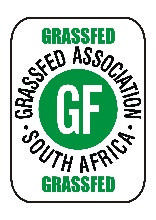

In [4]:
from io import BytesIO

from IPython.display import Image
from IPython.display import display as ipy_display
from PIL import Image as PILImage

for _, row in df[df["sample_id"] == sid].iterrows():
    if row["modality"] == "image":
        b = row["binary_content"]
        img = PILImage.open(BytesIO(b))
        thumb = img.copy()
        thumb.thumbnail((400, 400))
        buf = BytesIO()
        thumb.save(buf, format="PNG")
        ipy_display(Image(data=buf.getvalue(), format="png"))